In [7]:
import math
import csv
import random
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

from time import sleep
from collections import deque
from itertools import count

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from importnb import Notebook
with Notebook():
    from LabLatencyModel import LatencyModel, MultiDULatencyModel
    from LabCacheEngine import CacheEngineEnv
    from LabUserTileRequest import UserTileRequestEvents
    from LabEnvWrapper import EnvWrapper

import sys
# sys.path.append(r'c:\Users\es25591\Workspace\CacheVideoPredict360\Sources')
sys.path.append('/home/eduardo/Workspace/CacheVideoPredict360/Sources')
from Common.Utils import save_training_results


In [8]:
class Config:
    n_episodes: int = 100
    n_nodes: int = 3
    n_users: int = 200
    step_size: float = 10.0
    arrival_rate: float = 10.0  # users per second
    zipf_alpha: float = 1.0
    n_videos: int = 500
    n_gops: int = 30
    n_layers: int = 2
    n: int = 4
    m: int = 3
    n_tiles: int = n * m
    viewport: int = 4  # number of tiles in the viewport

    bas_layer_size: float = 2.0e+6  # 2 MB
    enh_layer_size: float = 1.5e+7  # 15 MB
    total_video_size: float = n_videos * (n_gops * bas_layer_size + viewport * enh_layer_size / n_tiles)  # 252 GB

    cache_capacity_percent: float = 0.20  # 10% of the total video size
    cache_capacity: float = cache_capacity_percent * total_video_size # 12.6 GB

    # CPT parameters
    theta: float = 0.5
    lam: float = 3.7183

    # Paths for data and results
    # path_data: str = r'c:\Users\es25591\Workspace\CacheVideoPredict360\Data'
    # path_results: str = r'c:\Users\es25591\Workspace\CacheVideoPredict360\Results'
    
    path_data: str = '/home/eduardo/Workspace/CacheVideoPredict360/Data'
    path_results: str = '/home/eduardo/Workspace/CacheVideoPredict360/Results'

In [ ]:
if __name__ == "__main__":

    # Configuration
    cfg = Config()

    du_caches = []

    mec_cache = CacheEngineEnv(
        n_users=cfg.n_users,
        n_videos=cfg.n_videos,
        n_layers=cfg.n_layers,
        n_tiles=cfg.n_tiles,
        n_gops=cfg.n_gops,
        cache_capacity=cfg.cache_capacity,
    )

    # Initialize User Environment
    users_env = UserTileRequestEvents(
        n_nodes=cfg.n_nodes,
        n_users=cfg.n_users,
        n_videos=cfg.n_videos,
        n_gops=cfg.n_gops,
        n_layers=cfg.n_layers,
        n_tiles=cfg.n_tiles,
        n=cfg.n,
        users_viewport_tiles=None,
        requested_videos=None,
        users_arrivals=None,
        arrival_rate=cfg.arrival_rate,
        zipf_alpha=cfg.zipf_alpha,
    )

    # Create latency model (replace numbers with your real config)
    P = cfg.n_nodes; max_U = cfg.n_users
    lat_model = MultiDULatencyModel(
        P=P, 
        max_U=max_U,
        R_M_D=80e6,   # 640 Mbps -> 80e6 B/s
        R_C_M=125e6, # 1 Gbps -> 125e6 B/s
        mu=2e7, 
        eta=2e5,
        B_pu_matrix=np.full((P, max_U), 40e6, dtype=float),    # 320 Mbps -> 40e6 B/s
        gamma_pu_matrix=np.full((P, max_U), 5.0, dtype=float), # SNRs
        rhoT_p=[0.2], 
        lambda_p=[0.05],
        du_fixed_delay=0.001,    # 1 ms
        mec_fixed_delay=0.005,   # 5 ms
        cloud_fixed_delay=0.1   # 100 ms
    )

    env = EnvWrapper(
        n=cfg.n,
        m=cfg.m,
        n_layers=cfg.n_layers,
        users_env=users_env, 
        du_caches=du_caches,
        mec_cache=mec_cache,
        latency_model=lat_model,
        theta=cfg.theta,
        lam=cfg.lam
    )

    print(
        f"Experiment ===================\n"
        f"Total users: {cfg.n_users}\n"
        f"Cache capacity: {int(cfg.cache_capacity/1e9)}GB\n"
        f"Video matrix: {cfg.n_videos}x{cfg.n_layers}x{cfg.n*cfg.n}\n"
        f"==============================\n"
    )

    results = []
    scores = []
    active_users_log = []  # Track active users per step

    for ep in range(cfg.n_episodes):

        obs, info = env.reset()

        cache_hits = 0
        cache_misses = 0
        enhanced_layer_cache_hits = 0
        enhanced_layer_cache_misses = 0
        base_layer_cache_hits = 0
        base_layer_cache_misses = 0
        total_reward = 0.0
        avg_psnr = []

        for step in count():

            req = info['user_request']
            if req:
                u, v, g = req['u'], req['video'], req['gop']
                base_req_init = req['base_req_init']

                tiles = np.zeros(cfg.n * cfg.m, dtype=int)
                for tile in req['tiles']:
                    tiles[tile['tile']] = 1 if tile['layer'] == 1 else 0

                # chooses tiles
                action = {
                    'user': u,
                    'gop': g + 1,
                    'video': v,
                    'base_req_init': base_req_init,
                    'tiles': tiles
                }
            else:
                action = None

            # --- STEP ENV ---
            obs, reward, done, info = env.step(action)

            total_reward += reward
            enhanced_layer_cache_hits += info["enh_layer_cache_hits"]
            enhanced_layer_cache_misses += info["enh_layer_cache_misses"]
            base_layer_cache_hits += info["base_layer_cache_hits"]
            base_layer_cache_misses += info["base_layer_cache_misses"]
            avg_psnr.append(info.get("average_psnr", 0.0))

            if done:
                break

        avg_psnr = [x for x in avg_psnr if x != 0.0]

        cache_hits = enhanced_layer_cache_hits + base_layer_cache_hits
        cache_misses = enhanced_layer_cache_misses + base_layer_cache_misses

        print(
            f"Episode {ep+1}/{cfg.n_episodes}, "
            f"Total Reward: {total_reward:.4f}, "
            f"cache_hits: {cache_hits}, "
            f"cache_misses: {cache_misses}, "
            f"enh_layer_cache_hits: {enhanced_layer_cache_hits}, "
            f"enh_layer_cache_misses: {enhanced_layer_cache_misses}, "
            f"base_layer_cache_hits: {base_layer_cache_hits}, "
            f"base_layer_cache_misses: {base_layer_cache_misses}, "
            f"Average PSNR: {np.mean(avg_psnr) if avg_psnr else 0.0:.2f}, "
        )

        filename = (
            f"lru_lsr_c{int(cfg.cache_capacity/1e9)}GB_"
            f"ar{int(cfg.arrival_rate)}_z{cfg.zipf_alpha}.csv"
        )

        save_training_results(
            path_=cfg.path_results,
            filename=filename,
            ep=ep,
            total_reward=total_reward,
            cache_hits=cache_hits,
            cache_misses=cache_misses,
            enhanced_layer_cache_hits=enhanced_layer_cache_hits,
            enhanced_layer_cache_misses=enhanced_layer_cache_misses,
            base_layer_cache_hits=base_layer_cache_hits,
            base_layer_cache_misses=base_layer_cache_misses,
            avg_psnr=np.mean(avg_psnr) if avg_psnr else 0.0,
            agent=None
        )
        scores.append(total_reward)

        results.append({
            "episode": ep,
            "total_reward": total_reward,
            "cache_hits": cache_hits,
            "cache_misses": cache_misses,
        })

Experiment ===================
Total users: 200
Cache capacity: 6GB
Video matrix: 500x2x16

Episode 1/100, Total Reward: -22051.3291, cache_hits: 50948, cache_misses: 45052, enh_layer_cache_hits: 12332, enh_layer_cache_misses: 11668, base_layer_cache_hits: 38616, base_layer_cache_misses: 33384, Average PSNR: 16.43, 
Episode 2/100, Total Reward: -20891.0001, cache_hits: 52248, cache_misses: 43752, enh_layer_cache_hits: 12924, enh_layer_cache_misses: 11076, base_layer_cache_hits: 39324, base_layer_cache_misses: 32676, Average PSNR: 16.63, 
Episode 3/100, Total Reward: -26521.2735, cache_hits: 45940, cache_misses: 50060, enh_layer_cache_hits: 11284, enh_layer_cache_misses: 12716, base_layer_cache_hits: 34656, base_layer_cache_misses: 37344, Average PSNR: 15.93, 
Episode 4/100, Total Reward: -30698.4580, cache_hits: 41260, cache_misses: 54740, enh_layer_cache_hits: 10648, enh_layer_cache_misses: 13352, base_layer_cache_hits: 30612, base_layer_cache_misses: 41388, Average PSNR: 14.76, 
Epis

/tmp/ipykernel_35461/3657158268.py:13: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axes[0].set_yscale('log')
/tmp/ipykernel_35461/3657158268.py:17: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[0].set_ylim(bottom=0)  # <--- Forces y-axis to start at 0
/tmp/ipykernel_35461/3657158268.py:27: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[1].set_ylim(bottom=0)  # <--- Forces y-axis to start at 0
/tmp/ipykernel_35461/3657158268.py:37: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[2].set_ylim(bottom=0)


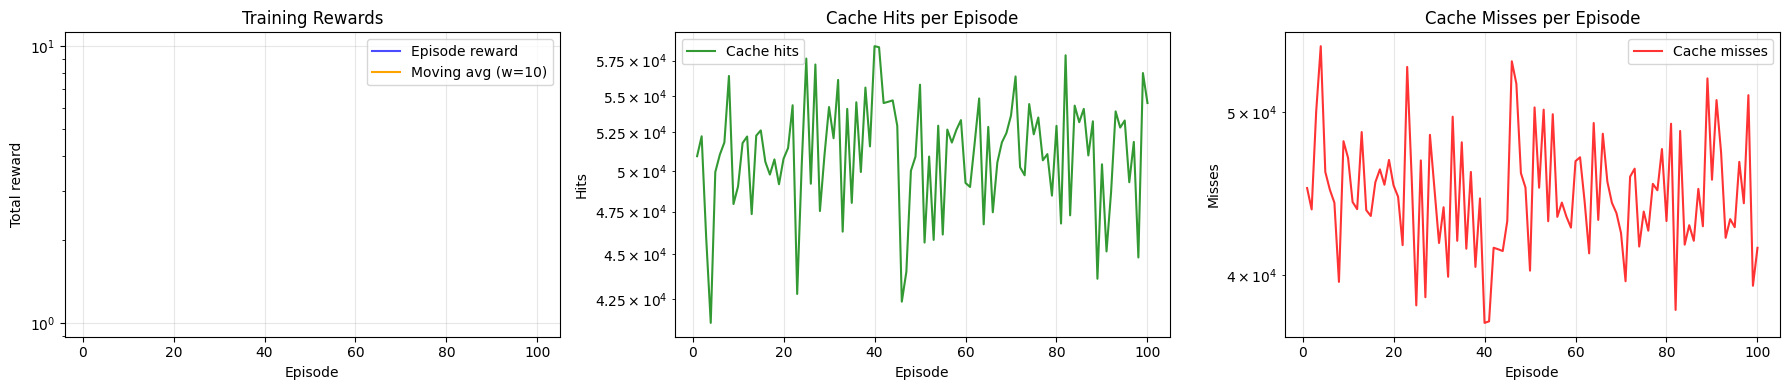

In [10]:
episodes = range(1, len(scores) + 1)
cache_hits_series = [r["cache_hits"] for r in results]
cache_misses_series = [r["cache_misses"] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)

# 1. Rewards with moving average
axes[0].plot(episodes, scores, label="Episode reward", alpha=0.7, color="blue")
w = max(1, min(20, len(scores) // 10))
if w > 1:
    ma = [sum(scores[i - w:i]) / w for i in range(w, len(scores) + 1)]
    axes[0].plot(range(w, len(scores) + 1), ma, label=f"Moving avg (w={w})", color="orange")
axes[0].set_yscale('log') 
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total reward")
axes[0].set_title("Training Rewards")
axes[0].set_ylim(bottom=0)  # <--- Forces y-axis to start at 0
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# 2. Cache hits
axes[1].plot(episodes, cache_hits_series, label="Cache hits", color="green", alpha=0.8)
axes[1].set_yscale('log') 
axes[1].set_title("Cache Hits per Episode")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Hits")
axes[1].set_ylim(bottom=0)  # <--- Forces y-axis to start at 0
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# 3. Cache misses
axes[2].plot(episodes, cache_misses_series, label="Cache misses", color="red", alpha=0.8)
axes[2].set_yscale('log')
axes[2].set_title("Cache Misses per Episode")
axes[2].set_xlabel("Episode")
axes[2].set_ylabel("Misses")
axes[2].set_ylim(bottom=0)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

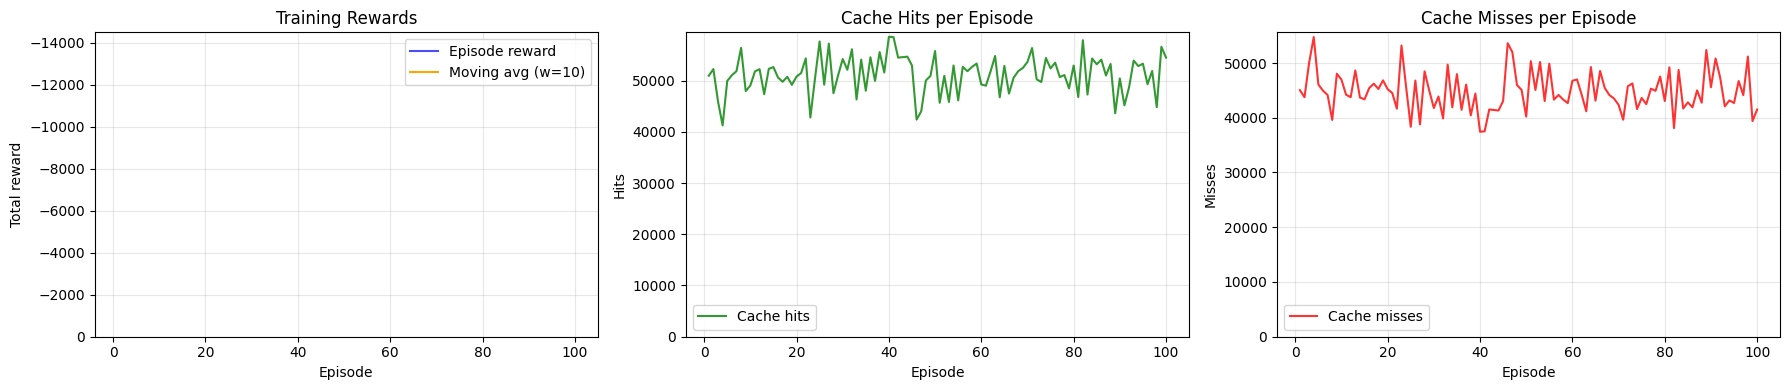

In [11]:
episodes = range(1, len(scores) + 1)
cache_hits_series = [r["cache_hits"] for r in results]
cache_misses_series = [r["cache_misses"] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)

# Rewards with moving average
axes[0].plot(episodes, scores, label="Episode reward", alpha=0.7, color="blue")
w = max(1, min(20, len(scores) // 10))
if w > 1:
    ma = [sum(scores[i - w:i]) / w for i in range(w, len(scores) + 1)]
    axes[0].plot(range(w, len(scores) + 1), ma, label=f"Moving avg (w={w})", color="orange")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total reward")
axes[0].set_title("Training Rewards")
axes[0].set_ylim(bottom=0)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Cache hits
axes[1].plot(episodes, cache_hits_series, label="Cache hits", color="green", alpha=0.8)
axes[1].set_title("Cache Hits per Episode")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Hits")
axes[1].set_ylim(bottom=0)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Cache misses
axes[2].plot(episodes, cache_misses_series, label="Cache misses", color="red", alpha=0.8)
axes[2].set_title("Cache Misses per Episode")
axes[2].set_xlabel("Episode")
axes[2].set_ylabel("Misses")
axes[2].set_ylim(bottom=0)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

In [12]:
from typing import List
import os

def read_results(csv_path: str):
    episodes: List[int] = []
    enhanced_hits: List[float] = []
    enhanced_misses: List[float] = []
    base_hits: List[float] = []
    base_misses: List[float] = []

    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV file not found: {csv_path}")

    with open(csv_path, "r", newline="") as f:
        reader = csv.DictReader(f)
        required_cols = [
            "episode",
            "enhanced_layer_cache_hits",
            "enhanced_layer_cache_misses",
            "base_layer_cache_hits",
            "base_layer_cache_misses",
        ]
        missing = [c for c in required_cols if c not in reader.fieldnames]
        if missing:
            raise ValueError(
                f"CSV missing required columns: {missing}. Found: {reader.fieldnames}"
            )

        for row in reader:
            try:
                episodes.append(int(row["episode"]))
                enhanced_hits.append(float(row["enhanced_layer_cache_hits"]))
                enhanced_misses.append(float(row["enhanced_layer_cache_misses"]))
                base_hits.append(float(row["base_layer_cache_hits"]))
                base_misses.append(float(row["base_layer_cache_misses"]))
            except (ValueError, KeyError):
                # skip malformed rows
                continue

    return episodes, enhanced_hits, enhanced_misses, base_hits, base_misses


def plot_cache_layers(
    csv_path: str,
    out_path: str | None = None,
    title: str | None = None,
):
    episodes, enhanced_hits, enhanced_misses, base_hits, base_misses = read_results(csv_path)

    # Compute per-episode percentages
    def safe_pct(num, den):
        return 0.0 if den == 0 else 100.0 * num / den

    enh_totals = [h + m for h, m in zip(enhanced_hits, enhanced_misses)]
    base_totals = [h + m for h, m in zip(base_hits, base_misses)]

    enh_hit_rate = [safe_pct(h, t) for h, t in zip(enhanced_hits, enh_totals)]
    enh_miss_rate = [safe_pct(m, t) for m, t in zip(enhanced_misses, enh_totals)]
    base_hit_rate = [safe_pct(h, t) for h, t in zip(base_hits, base_totals)]
    base_miss_rate = [safe_pct(m, t) for m, t in zip(base_misses, base_totals)]

    # Shared y-lims per layer type (percentages)
    enh_ylim = (0, 100)
    base_ylim = (0, 100)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Enhanced Layer: Hit rate
    axes[0, 0].plot(episodes, enh_hit_rate, label="Enhanced hit rate (%)", color="blue", alpha=0.9)
    axes[0, 0].set_title("Enhanced Layer Hit Rate")
    axes[0, 0].set_xlabel("Episode")
    axes[0, 0].set_ylabel("Rate (%)")
    axes[0, 0].set_ylim(enh_ylim)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

    # Enhanced Layer: Miss rate
    axes[0, 1].plot(episodes, enh_miss_rate, label="Enhanced miss rate (%)", color="red", alpha=0.9)
    axes[0, 1].set_title("Enhanced Layer Miss Rate")
    axes[0, 1].set_xlabel("Episode")
    axes[0, 1].set_ylabel("Rate (%)")
    axes[0, 1].set_ylim(enh_ylim)
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

    # Base Layer: Hit rate
    axes[1, 0].plot(episodes, base_hit_rate, label="Base hit rate (%)", color="green", alpha=0.9)
    axes[1, 0].set_title("Base Layer Hit Rate")
    axes[1, 0].set_xlabel("Episode")
    axes[1, 0].set_ylabel("Rate (%)")
    axes[1, 0].set_ylim(base_ylim)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()

    # Base Layer: Miss rate
    axes[1, 1].plot(episodes, base_miss_rate, label="Base miss rate (%)", color="orange", alpha=0.9)
    axes[1, 1].set_title("Base Layer Miss Rate")
    axes[1, 1].set_xlabel("Episode")
    axes[1, 1].set_ylabel("Rate (%)")
    axes[1, 1].set_ylim(base_ylim)
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()

    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()

    if out_path:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()


if __name__ == "__main__":
    csv_filepath = '/home/eduardo/Workspace/CacheVideoPredict360/Results'
    # csv_filepath = r'c:\Users\es25591\Workspace\CacheVideoPredict360\Results\fov_predictor_U500_V1000_G60_L2_N4_cap150MB_eps0.05_2.csv'
    csv_filepath += '/fov_predictor_U500_V1000_G60_L2_N4_cap300MB_eps0.05_2.csv'
    
    #out_path = r'c:\Users\es25591\Workspace\CacheVideoPredict360\Results\fov_predictor_U500_V1000_G60_L2_N4_cap150MB_eps0.05_2.png'
    out_path = None

    title = "FOV Predictor DQN Agent Cache Layers Performance"

    plot_cache_layers(
        csv_filepath, 
        out_path=None, 
        title=title
    )


FileNotFoundError: CSV file not found: /home/eduardo/Workspace/CacheVideoPredict360/Results/fov_predictor_U500_V1000_G60_L2_N4_cap300MB_eps0.05_2.csv

In [ ]:
from typing import List
import os

def read_results(csv_path: str):
    episodes: List[int] = []
    enhanced_hits: List[float] = []
    enhanced_misses: List[float] = []
    base_hits: List[float] = []
    base_misses: List[float] = []

    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV file not found: {csv_path}")

    with open(csv_path, "r", newline="") as f:
        reader = csv.DictReader(f)
        required_cols = [
            "episode",
            "enhanced_layer_cache_hits",
            "enhanced_layer_cache_misses",
            "base_layer_cache_hits",
            "base_layer_cache_misses",
        ]
        missing = [c for c in required_cols if c not in reader.fieldnames]
        if missing:
            raise ValueError(
                f"CSV missing required columns: {missing}. Found: {reader.fieldnames}"
            )

        for row in reader:
            try:
                episodes.append(int(row["episode"]))
                enhanced_hits.append(float(row["enhanced_layer_cache_hits"]))
                enhanced_misses.append(float(row["enhanced_layer_cache_misses"]))
                base_hits.append(float(row["base_layer_cache_hits"]))
                base_misses.append(float(row["base_layer_cache_misses"]))
            except (ValueError, KeyError):
                # skip malformed rows
                continue

    return episodes, enhanced_hits, enhanced_misses, base_hits, base_misses


def plot_cache_layers(
    csv_path: str,
    out_path: str | None = None,
    title: str | None = None,
):
    episodes, enhanced_hits, enhanced_misses, base_hits, base_misses = read_results(csv_path)

    # Compute shared y-lims per layer type
    def compute_ylim(a, b, pad=0.05, min_top=1.0):
        top = max(max(a or [0.0]), max(b or [0.0]))
        top = max(min_top, top)
        return (0, top * (1 + pad))

    enh_ylim = compute_ylim(enhanced_hits, enhanced_misses)
    base_ylim = compute_ylim(base_hits, base_misses)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Enhanced Layer Cache Hits
    axes[0, 0].plot(episodes, enhanced_hits, label="Enhanced layer hits", color="blue", alpha=0.8)
    axes[0, 0].set_title("Enhanced Layer Cache Hits per Episode")
    axes[0, 0].set_xlabel("Episode")
    axes[0, 0].set_ylabel("Hits")
    axes[0, 0].set_ylim(enh_ylim)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

    # Plot 2: Enhanced Layer Cache Misses
    axes[0, 1].plot(episodes, enhanced_misses, label="Enhanced layer misses", color="red", alpha=0.8)
    axes[0, 1].set_title("Enhanced Layer Cache Misses per Episode")
    axes[0, 1].set_xlabel("Episode")
    axes[0, 1].set_ylabel("Misses")
    axes[0, 1].set_ylim(enh_ylim)
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

    # Plot 3: Base Layer Cache Hits
    axes[1, 0].plot(episodes, base_hits, label="Base layer hits", color="green", alpha=0.8)
    axes[1, 0].set_title("Base Layer Cache Hits per Episode")
    axes[1, 0].set_xlabel("Episode")
    axes[1, 0].set_ylabel("Hits")
    axes[1, 0].set_ylim(base_ylim)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()

    # Plot 4: Base Layer Cache Misses
    axes[1, 1].plot(episodes, base_misses, label="Base layer misses", color="orange", alpha=0.8)
    axes[1, 1].set_title("Base Layer Cache Misses per Episode")
    axes[1, 1].set_xlabel("Episode")
    axes[1, 1].set_ylabel("Misses")
    axes[1, 1].set_ylim(base_ylim)
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    csv_filepath = r'c:\Users\es25591\Workspace\CacheVideoPredict360\Results\fov_predictor_U500_V1000_G60_L2_N4_cap100MB_eps0.05_2.csv'
    
    out_path = r'c:\Users\es25591\Workspace\CacheVideoPredict360\Results\fov_predictor_U500_V1000_G60_L2_N4_cap100MB_eps0.05_2_layers.png'

    title = "FOV Predictor DQN Agent Cache Layers Performance"

    plot_cache_layers(
        csv_filepath, 
        out_path=None, 
        title=title
    )
